In [1]:
# Install any missing libraries
# !pip install pandas scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, confusion_matrix,
                             classification_report)


In [2]:
# Load the feature names
features = pd.read_csv('NUSW-NB15_features.csv', encoding='latin-1')
col_names = features['Name'].tolist()  # Extract column names
col_names

['srcip',
 'sport',
 'dstip',
 'dsport',
 'proto',
 'state',
 'dur',
 'sbytes',
 'dbytes',
 'sttl',
 'dttl',
 'sloss',
 'dloss',
 'service',
 'Sload',
 'Dload',
 'Spkts',
 'Dpkts',
 'swin',
 'dwin',
 'stcpb',
 'dtcpb',
 'smeansz',
 'dmeansz',
 'trans_depth',
 'res_bdy_len',
 'Sjit',
 'Djit',
 'Stime',
 'Ltime',
 'Sintpkt',
 'Dintpkt',
 'tcprtt',
 'synack',
 'ackdat',
 'is_sm_ips_ports',
 'ct_state_ttl',
 'ct_flw_http_mthd',
 'is_ftp_login',
 'ct_ftp_cmd',
 'ct_srv_src',
 'ct_srv_dst',
 'ct_dst_ltm',
 'ct_src_ ltm',
 'ct_src_dport_ltm',
 'ct_dst_sport_ltm',
 'ct_dst_src_ltm',
 'attack_cat',
 'Label']

In [3]:
# Load all 4 CSV files and combine them
df1 = pd.read_csv('UNSW-NB15_1.csv', header=None, names=col_names, low_memory=False)
df2 = pd.read_csv('UNSW-NB15_2.csv', header=None, names=col_names, low_memory=False)
df3 = pd.read_csv('UNSW-NB15_3.csv', header=None, names=col_names, low_memory=False)
df4 = pd.read_csv('UNSW-NB15_4.csv', header=None, names=col_names, low_memory=False)

# Combine into one dataframe
df = pd.concat([df1, df2, df3, df4], ignore_index=True)

print(f"Dataset shape: {df.shape}")
print(f"Total rows: {df.shape[0]:,}")
print(f"Total columns: {df.shape[1]}")

Dataset shape: (2508519, 49)
Total rows: 2,508,519
Total columns: 49


In [4]:
df.head()

,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,...,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,Label
0,59.166.0.0,1390,149.171.126.6,53,udp,CON,0.001055,132,164,31,...,0,3.0,7.0,1.0,3.0,1.0,1.0,1.0,NaN,0.0
1,59.166.0.0,33661,149.171.126.9,1024,udp,CON,0.036133,528,304,31,...,0,2.0,4.0,2.0,3.0,1.0,1.0,2.0,NaN,0.0
2,59.166.0.6,1464,149.171.126.7,53,udp,CON,0.001119,146,178,31,...,0,12.0,8.0,1.0,2.0,2.0,1.0,1.0,NaN,0.0
3,59.166.0.5,3593,149.171.126.5,53,udp,CON,0.001209,132,164,31,...,0,6.0,9.0,1.0,1.0,1.0,1.0,1.0,NaN,0.0
4,59.166.0.3,49664,149.171.126.0,53,udp,CON,0.001169,146,178,31,...,0,7.0,9.0,1.0,1.0,1.0,1.0,1.0,NaN,0.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2508519 entries, 0 to 2508518
Data columns (total 49 columns):
 #   Column            Dtype  
---  ------            -----  
 0   srcip             object 
 1   sport             object 
 2   dstip             object 
 3   dsport            object 
 4   proto             object 
 5   state             object 
 6   dur               float64
 7   sbytes            int64  
 8   dbytes            int64  
 9   sttl              int64  
 10  dttl              int64  
 11  sloss             int64  
 12  dloss             int64  
 13  service           object 
 14  Sload             float64
 15  Dload             float64
 16  Spkts             int64  
 17  Dpkts             int64  
 18  swin              int64  
 19  dwin              int64  
 20  stcpb             int64  
 21  dtcpb             float64
 22  smeansz           float64
 23  dmeansz           float64
 24  trans_depth       float64
 25  res_bdy_len       float64
 26  Sjit          

In [6]:
print(df['Label'].value_counts())
print("\nClass distribution (%):")
print(df['Label'].value_counts(normalize=True) * 100)

Label
0.0    2192881
1.0     315637
Name: count, dtype: int64

Class distribution (%):
Label
0.0    87.417391
1.0    12.582609
Name: proportion, dtype: float64


In [7]:
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Missing values per column:
dtcpb                     1
smeansz                   1
dmeansz                   1
trans_depth               1
res_bdy_len               1
Sjit                      1
Djit                      1
Stime                     1
Ltime                     1
Sintpkt                   1
Dintpkt                   1
tcprtt                    1
synack                    1
ackdat                    1
is_sm_ips_ports           1
ct_state_ttl              1
ct_flw_http_mthd    1319407
is_ftp_login        1398840
ct_ftp_cmd                1
ct_srv_src                1
ct_srv_dst                1
ct_dst_ltm                1
ct_src_ ltm               1
ct_src_dport_ltm          1
ct_dst_sport_ltm          1
ct_dst_src_ltm            1
attack_cat          2192882
Label                     1
dtype: int64


In [8]:
df['Label'].value_counts()

Label
0.0    2192881
1.0     315637
Name: count, dtype: int64

In [9]:
# Drop unnecessary columns
df.drop(columns=['srcip', 'dstip', 'attack_cat', 'ct_flw_http_mthd', 'is_ftp_login'], inplace=True)

# Drop the one row where Label is missing
df.dropna(subset=['Label'], inplace=True)

print(f"Shape after dropping columns: {df.shape}")

Shape after dropping columns: (2508518, 44)


In [10]:
df['ct_ftp_cmd'] = pd.to_numeric(df['ct_ftp_cmd'], errors='coerce')
print("ct_ftp_cmd dtype:", df['ct_ftp_cmd'].dtype)

ct_ftp_cmd dtype: float64


In [11]:
# Fill numeric columns with median
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

print("Missing values remaining:", df.isnull().sum().sum())

Missing values remaining: 0


In [12]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", cat_cols)

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

Categorical columns to encode: ['sport', 'dsport', 'proto', 'state', 'service']


In [13]:
X = df.drop(columns=['Label'])
y = df['Label']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (2508518, 43)
Target shape: (2508518,)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

Training set: (2006814, 43)
Testing set: (501704, 43)


In [15]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
model = LogisticRegression(
    max_iter=1000,       
    class_weight='balanced',  # Handles the class imbalance
    random_state=42,
)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [17]:
y_pred = model.predict(X_test)

In [18]:
print(f"Accuracy:  {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred) * 100:.2f}%")
print(f"Recall:    {recall_score(y_test, y_pred) * 100:.2f}%")
print("\nFull Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Attack']))

Accuracy:  98.73%
Precision: 90.95%
Recall:    99.87%

Full Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99    438577
      Attack       0.91      1.00      0.95     63127

    accuracy                           0.99    501704
   macro avg       0.95      0.99      0.97    501704
weighted avg       0.99      0.99      0.99    501704



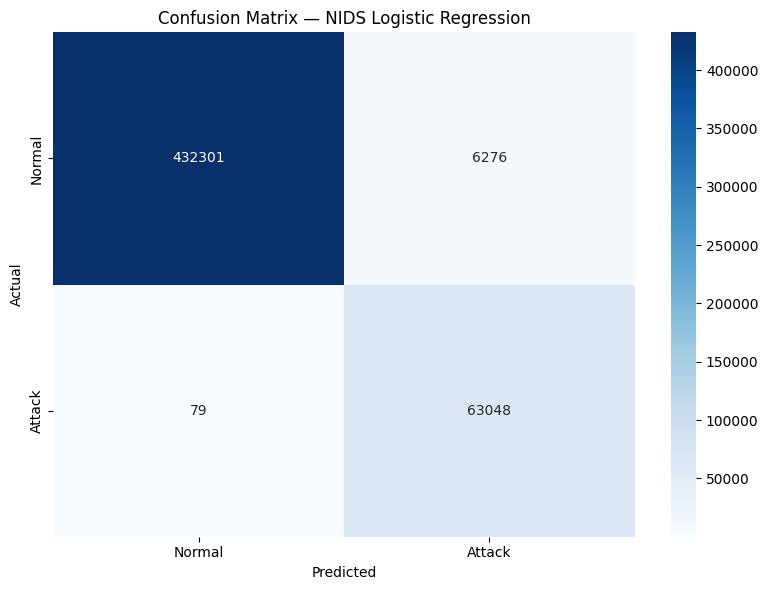

In [19]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.title('Confusion Matrix — NIDS Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [22]:
# Get indices of false positives and false negatives
fp_idx = np.where((y_pred == 1) & (y_test.values == 0))[0]
fn_idx = np.where((y_pred == 0) & (y_test.values == 1))[0]

print(f"False Positives (Normal flagged as Attack): {len(fp_idx):,}")
print(f"False Negatives (Attack missed by model):   {len(fn_idx):,}")

False Positives (Normal flagged as Attack): 6,276
False Negatives (Attack missed by model):   79


In [23]:
# Get the test set rows from the original dataframe
X_test_df = df.drop(columns=['Label']).iloc[y_test.index]
X_test_df = X_test_df.copy()
X_test_df['Label'] = y_test.values
X_test_df['Predicted'] = y_pred

# Separate false positives and false negatives
false_positives = X_test_df.iloc[fp_idx]
false_negatives = X_test_df.iloc[fn_idx]

print(f"False Positives shape: {false_positives.shape}")
print(f"False Negatives shape: {false_negatives.shape}")

False Positives shape: (6276, 45)
False Negatives shape: (79, 45)


In [24]:
# Re-load attack categories from original dataframe before it was dropped
attack_cat_series = pd.concat([df1, df2, df3, df4], ignore_index=True)['attack_cat']
attack_cat_series = attack_cat_series.iloc[y_test.index].reset_index(drop=True)

X_test_df['attack_cat'] = attack_cat_series.values
false_negatives = X_test_df.iloc[fn_idx].copy()


=== FALSE NEGATIVES — Attacks the model MISSED ===

attack_cat
Exploits            43
DoS                 14
Generic              7
 Fuzzers             5
Analysis             2
 Shellcode           2
Backdoor             2
Worms                1
 Reconnaissance      1
Backdoors            1
 Fuzzers             1
Name: count, dtype: int64

Total missed attacks: 79


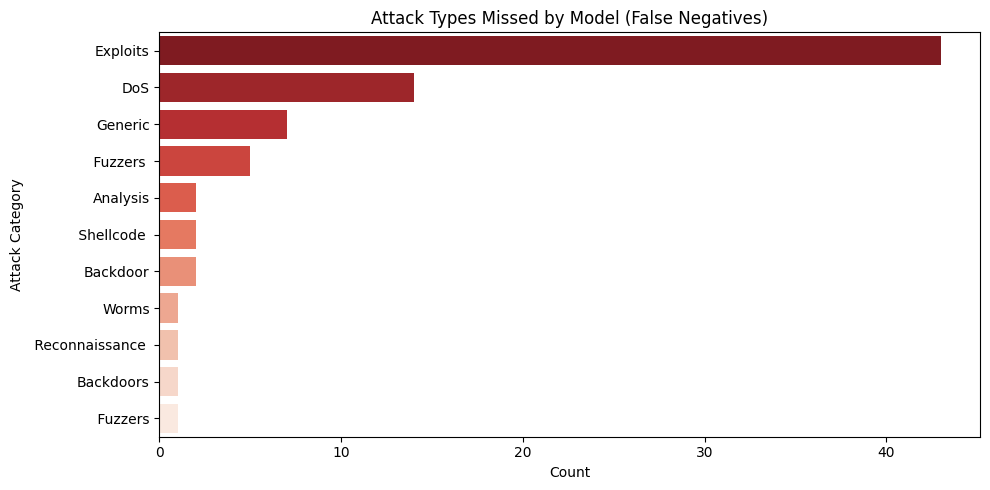

In [25]:
print("=== FALSE NEGATIVES — Attacks the model MISSED ===\n")
missed_attacks = false_negatives['attack_cat'].value_counts()
print(missed_attacks)
print(f"\nTotal missed attacks: {len(false_negatives):,}")

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x=missed_attacks.values, y=missed_attacks.index, 
            hue=missed_attacks.index, palette='Reds_r', legend=False)
plt.title('Attack Types Missed by Model (False Negatives)')
plt.xlabel('Count')
plt.ylabel('Attack Category')
plt.tight_layout()
plt.savefig('false_negatives_by_attack.png', dpi=150)
plt.show()

In [26]:
print("=== ERROR RATE PER ATTACK TYPE ===\n")

# Get all attacks in test set with their categories
all_attacks = X_test_df[X_test_df['Label'] == 1].copy()
total_per_type = all_attacks['attack_cat'].value_counts()
missed_per_type = false_negatives['attack_cat'].value_counts()

error_rate = (missed_per_type / total_per_type * 100).fillna(0).sort_values(ascending=False)
error_df = pd.DataFrame({
    'Attack Type': error_rate.index,
    'Total': total_per_type[error_rate.index].values,
    'Missed': missed_per_type.reindex(error_rate.index, fill_value=0).values,
    'Miss Rate (%)': error_rate.values.round(2)
})

print(error_df.to_string(index=False))

=== ERROR RATE PER ATTACK TYPE ===

     Attack Type  Total  Missed  Miss Rate (%)
           Worms     32       1           3.12
       Backdoors     95       1           1.05
      Shellcode     250       2           0.80
        Backdoor    345       2           0.58
        Exploits   8729      43           0.49
             DoS   3297      14           0.42
        Analysis    558       2           0.36
        Fuzzers    3680       5           0.14
         Fuzzers   1025       1           0.10
 Reconnaissance    2369       1           0.04
         Generic  42384       7           0.02
  Reconnaissance    315       0           0.00
       Shellcode     48       0           0.00


In [27]:
import joblib

joblib.dump(model, 'nids_model.pkl')
joblib.dump(scaler, 'nids_scaler.pkl')

['nids_scaler.pkl']

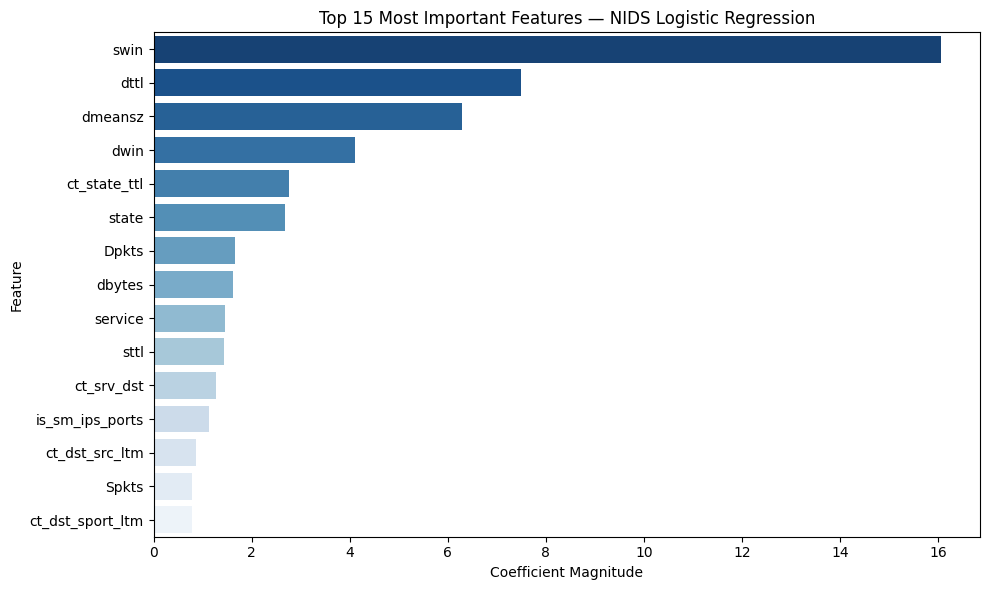

In [28]:
# Get feature importances from logistic regression coefficients
feature_names = X.columns.tolist()
coefficients = np.abs(model.coef_[0])

# Create a dataframe and sort by importance
feat_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': coefficients
}).sort_values('Importance', ascending=False).head(15)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_importance, x='Importance', y='Feature',
            hue='Feature', palette='Blues_r', legend=False)
plt.title('Top 15 Most Important Features — NIDS Logistic Regression')
plt.xlabel('Coefficient Magnitude')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()